# CODIGO CON ENFOQUE HIBRIDO CNN + SVM 

In [ ]:
import cv2
import numpy as np
import joblib
import os
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array
from sklearn import svm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


# Parámetros
image_size = (128, 128)  # Ajuste del tamaño de la imagen
train_dir = '/home/ramiro/Documentos/Proyecto_clasificador_de_imagenes_v2/Proyecto_clasificador_de_imagenes/Training_set'


# Configuración de modelo CNN preentrenado
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
model = Model(inputs=base_model.input, outputs=base_model.output)

# Función para cargar y procesar imágenes usando VGG16
def load_and_process_images(data_dir):
    features = []
    labels = []
    class_names = sorted(os.listdir(data_dir))
    
    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            image = cv2.imread(img_path)
            image = cv2.resize(image, (128, 128))
            image = img_to_array(image) / 255.0
            image = np.expand_dims(image, axis=0)
            feature = model.predict(image).flatten()
            features.append(feature)
            labels.append(label)
    
    features = np.array(features)
    labels = np.array(labels)
    return features, labels

# Cargar datos y dividir en entrenamiento y validación
features, labels = load_and_process_images(train_dir)
train_features, val_features, train_labels, val_labels = train_test_split(features, labels, test_size=0.4, random_state=42)

# Escalado de características
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
val_features = scaler.transform(val_features)


# Configuración de SVM con GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf']
}
grid_search = GridSearchCV(svm.SVC(), param_grid, cv=5)
grid_search.fit(train_features, train_labels)

# Evaluar el modelo con el mejor estimador
svm_model = grid_search.best_estimator_
train_predictions = svm_model.predict(train_features)
val_predictions = svm_model.predict(val_features)

train_accuracy = accuracy_score(train_labels, train_predictions)
val_accuracy = accuracy_score(val_labels, val_predictions)

print(f"Precisión en el conjunto de entrenamiento: {train_accuracy * 100:.2f}%")
print(f"Precisión en el conjunto de validación: {val_accuracy * 100:.2f}%")

# Guardar el modelo
output_model_path = "modelo_cnn_svm.pkl"
joblib.dump((svm_model, scaler, model), output_model_path)
print(f"Modelo CNN + SVM guardado exitosamente en {output_model_path}")

# Función de predicción
def predecir_especie(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"No se pudo cargar la imagen: {image_path}")
        return "Error en la carga de la imagen."
    
    image = cv2.resize(image, (128, 128))
    image = img_to_array(image) / 255.0
    image = np.expand_dims(image, axis=0)
    feature = model.predict(image).flatten()
    feature = scaler.transform([feature])
    
    prediccion = svm_model.predict(feature)[0]
    especie = "Akodon Azarae" if prediccion == 0 else "Calomys musculinus"
    return especie

# Ejemplo de uso
image_prueba_path = "/home/ramirotizzian/Documentos/PROYECTO_FINAL_TDI/Proyecto_clasificador_de_imagenes/Imagenes_prueba/Captura desde 2024-11-10 00-50-06.png"
especie_predicha = predecir_especie(image_prueba_path)
print(f"La imagen pertenece a la especie: {especie_predicha}")


Precisión en el conjunto de entrenamiento: 100.00%
Precisión en el conjunto de validación: 98.85%


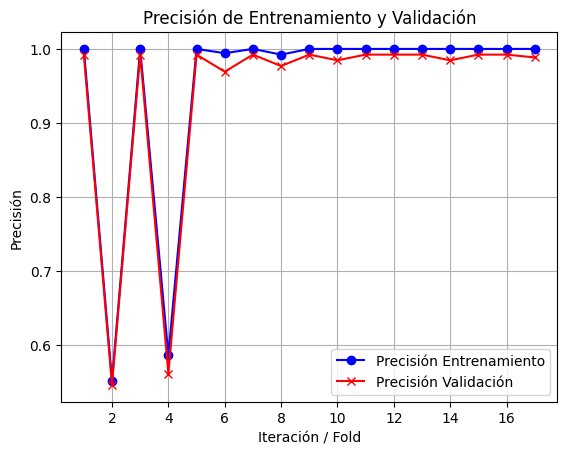

Modelo CNN + SVM guardado exitosamente en modelo_cnn_svm.pkl


In [2]:
import cv2
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import svm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Lista para almacenar las precisiones de entrenamiento y validación durante el proceso
train_accuracies = []
val_accuracies = []

# Configuración de SVM con GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf']
}
grid_search = GridSearchCV(svm.SVC(), param_grid, cv=5, return_train_score=True)  # Guardar precisión de entrenamiento
grid_search.fit(train_features, train_labels)

# Guardar las precisiones en cada fold de validación
for i in range(len(grid_search.cv_results_['mean_train_score'])):
    train_accuracies.append(grid_search.cv_results_['mean_train_score'][i])
    val_accuracies.append(grid_search.cv_results_['mean_test_score'][i])

# Evaluar el modelo con el mejor estimador
svm_model = grid_search.best_estimator_
train_predictions = svm_model.predict(train_features)
val_predictions = svm_model.predict(val_features)

train_accuracy = accuracy_score(train_labels, train_predictions)
val_accuracy = accuracy_score(val_labels, val_predictions)

train_accuracies.append(train_accuracy)
val_accuracies.append(val_accuracy)

print(f"Precisión en el conjunto de entrenamiento: {train_accuracy * 100:.2f}%")
print(f"Precisión en el conjunto de validación: {val_accuracy * 100:.2f}%")

# Graficar las precisiones de entrenamiento y validación
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Precisión Entrenamiento', color='blue', marker='o')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Precisión Validación', color='red', marker='x')
plt.xlabel('Iteración / Fold')
plt.ylabel('Precisión')
plt.title('Precisión de Entrenamiento y Validación')
plt.legend()
plt.grid(True)
plt.show()

# Guardar el modelo
output_model_path = "modelo_cnn_svm.pkl"
joblib.dump((svm_model, scaler, model), output_model_path)
print(f"Modelo CNN + SVM guardado exitosamente en {output_model_path}")


# CODIGO CNN + SVM CON AUMENTO DE DATOS CON ImageDataGenrator para incluir variaciones de escala en las imagenes de entrenamiento

In [ ]:
import cv2
import numpy as np
import joblib
import os
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
from sklearn import svm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Configuración de modelo CNN preentrenado para extracción de características
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
model = Model(inputs=base_model.input, outputs=base_model.output)

# Generador de aumento de datos
datagen = ImageDataGenerator(
    zoom_range=[0.5, 1.5],      # Escalas entre la mitad y una vez y media el tamaño original
    rotation_range=10,          # Rotaciones pequeñas
    width_shift_range=0.1,      # Desplazamiento horizontal
    height_shift_range=0.1,     # Desplazamiento vertical
    horizontal_flip=True,       # Inversión horizontal
)

# Función para cargar, aumentar y procesar imágenes
def load_and_augment_images(data_dir):
    features = []
    labels = []
    class_names = sorted(os.listdir(data_dir))
    
    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            image = cv2.imread(img_path)
            image = cv2.resize(image, (128, 128))
            image = img_to_array(image) / 255.0
            image = np.expand_dims(image, axis=0)
            
            # Generar aumentos para la imagen actual
            for augmented_image in datagen.flow(image, batch_size=1):
                feature = model.predict(augmented_image).flatten()
                features.append(feature)
                labels.append(label)
                # Limitar el número de aumentos por imagen original para no generar excesivos datos
                if len(features) % 5 == 0:
                    break

    features = np.array(features)
    labels = np.array(labels)
    return features, labels

# Cargar, aumentar y dividir datos en entrenamiento y validación
features, labels = load_and_augment_images(train_dir)
train_features, val_features, train_labels, val_labels = train_test_split(features, labels, test_size=0.4, random_state=42)

# Escalado de características
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
val_features = scaler.transform(val_features)

# Configuración de SVM con GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf']
}
grid_search = GridSearchCV(svm.SVC(), param_grid, cv=5)
grid_search.fit(train_features, train_labels)

# Evaluación del mejor modelo SVM
svm_model = grid_search.best_estimator_
train_predictions = svm_model.predict(train_features)
val_predictions = svm_model.predict(val_features)

train_accuracy = accuracy_score(train_labels, train_predictions)
val_accuracy = accuracy_score(val_labels, val_predictions)

print(f"Precisión en el conjunto de entrenamiento: {train_accuracy * 100:.2f}%")
print(f"Precisión en el conjunto de validación: {val_accuracy * 100:.2f}%")

# Guardar el modelo y el escalador
output_model_path = "modelo_cnn_svm_aumentado.pkl"
joblib.dump((svm_model, scaler, model), output_model_path)
print(f"Modelo CNN + SVM con aumento de datos guardado exitosamente en {output_model_path}")

# Función de predicción
def predecir_especie(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"No se pudo cargar la imagen: {image_path}")
        return "Error en la carga de la imagen."
    
    image = cv2.resize(image, (128, 128))
    image = img_to_array(image) / 255.0
    image = np.expand_dims(image, axis=0)
    feature = model.predict(image).flatten()
    feature = scaler.transform([feature])
    
    prediccion = svm_model.predict(feature)[0]
    especie = "Akodon Azarae" if prediccion == 0 else "Calomys musculinus"
    return especie

# Ejemplo de uso
image_prueba_path = "/home/ramirotizzian/Documentos/PROYECTO_FINAL_TDI/Proyecto_clasificador_de_imagenes/Imagenes_prueba/Captura desde 2024-11-05 21-04-38.png"
especie_predicha = predecir_especie(image_prueba_path)
print(f"La imagen pertenece a la especie: {especie_predicha}")


In [ ]:
import cv2
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import svm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Lista para almacenar las precisiones de entrenamiento y validación durante el proceso
train_accuracies = []
val_accuracies = []

# Configuración de SVM con GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf']
}
grid_search = GridSearchCV(svm.SVC(), param_grid, cv=5, return_train_score=True)  # Guardar precisión de entrenamiento
grid_search.fit(train_features, train_labels)

# Guardar las precisiones en cada fold de validación
for i in range(len(grid_search.cv_results_['mean_train_score'])):
    train_accuracies.append(grid_search.cv_results_['mean_train_score'][i])
    val_accuracies.append(grid_search.cv_results_['mean_test_score'][i])

# Evaluar el modelo con el mejor estimador
svm_model = grid_search.best_estimator_
train_predictions = svm_model.predict(train_features)
val_predictions = svm_model.predict(val_features)

train_accuracy = accuracy_score(train_labels, train_predictions)
val_accuracy = accuracy_score(val_labels, val_predictions)

train_accuracies.append(train_accuracy)
val_accuracies.append(val_accuracy)

print(f"Precisión en el conjunto de entrenamiento: {train_accuracy * 100:.2f}%")
print(f"Precisión en el conjunto de validación: {val_accuracy * 100:.2f}%")

# Graficar las precisiones de entrenamiento y validación
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Precisión Entrenamiento', color='blue', marker='o')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Precisión Validación', color='red', marker='x')
plt.xlabel('Iteración / Fold')
plt.ylabel('Precisión')
plt.title('Precisión de Entrenamiento y Validación')
plt.legend()
plt.grid(True)
plt.show()

# Guardar el modelo
output_model_path = "modelo_cnn_svm.pkl"
joblib.dump((svm_model, scaler, model), output_model_path)
print(f"Modelo CNN + SVM guardado exitosamente en {output_model_path}")


# MODELO HIBRIDO CNN + SVM CON NORMALIZACION DE LA IMAGEN DE PRUEBA A 128 X 128 (TAMBIEN FUNCIONA)

In [ ]:
import cv2
import numpy as np
import joblib
import os
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
from sklearn import svm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Configuración de modelo CNN preentrenado para extracción de características
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
model = Model(inputs=base_model.input, outputs=base_model.output)

# Generador de aumento de datos
'''datagen = ImageDataGenerator(
    zoom_range=[0.5, 1.5],
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)'''

# Función para cargar, aumentar y procesar imágenes
def load_and_augment_images(data_dir):
    features = []
    labels = []
    class_names = sorted(os.listdir(data_dir))
    
    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            image = cv2.imread(img_path)
            image = cv2.resize(image, (128, 128))
            image = img_to_array(image) / 255.0
            image = np.expand_dims(image, axis=0)
            
            # Generar aumentos para la imagen actual
            for augmented_image in datagen.flow(image, batch_size=1):
                feature = model.predict(augmented_image).flatten()
                features.append(feature)
                labels.append(label)
                if len(features) % 5 == 0:
                    break

    features = np.array(features)
    labels = np.array(labels)
    return features, labels

# Cargar, aumentar y dividir datos en entrenamiento y validación
features, labels = load_and_augment_images(train_dir)
train_features, val_features, train_labels, val_labels = train_test_split(features, labels, test_size=0.4, random_state=42)

# Escalado de características
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
val_features = scaler.transform(val_features)

# Configuración de SVM con GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf']
}
grid_search = GridSearchCV(svm.SVC(), param_grid, cv=5)
grid_search.fit(train_features, train_labels)

# Evaluación del mejor modelo SVM
svm_model = grid_search.best_estimator_
train_predictions = svm_model.predict(train_features)
val_predictions = svm_model.predict(val_features)

train_accuracy = accuracy_score(train_labels, train_predictions)
val_accuracy = accuracy_score(val_labels, val_predictions)

print(f"Precisión en el conjunto de entrenamiento: {train_accuracy * 100:.2f}%")
print(f"Precisión en el conjunto de validación: {val_accuracy * 100:.2f}%")

# Guardar el modelo y el escalador
output_model_path = "modelo_cnn_svm_aumentado.pkl"
joblib.dump((svm_model, scaler, model), output_model_path)
print(f"Modelo CNN + SVM con aumento de datos guardado exitosamente en {output_model_path}")

# Función de predicción con normalización de escala
def predecir_especie(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"No se pudo cargar la imagen: {image_path}")
        return "Error en la carga de la imagen."
    
    # Redimensionar y normalizar la imagen de prueba a 128x128
    image = cv2.resize(image, (128, 128))
    image = img_to_array(image) / 255.0
    image = np.expand_dims(image, axis=0)
    
    # Extraer características de la imagen normalizada
    feature = model.predict(image).flatten()
    feature = scaler.transform([feature])  # Escalar características
    
    # Realizar la predicción
    prediccion = svm_model.predict(feature)[0]
    especie = "Akodon Azarae" if prediccion == 0 else "Calomys musculinus"
    return especie

# Ejemplo de uso
image_prueba_path = "/home/ramirotizzian/Documentos/PROYECTO_FINAL_TDI/Proyecto_clasificador_de_imagenes/Imagenes_prueba/Captura desde 2024-11-10 00-50-06.png"
especie_predicha = predecir_especie(image_prueba_path)
print(f"La imagen pertenece a la especie: {especie_predicha}")
